In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import barycentric_interpolate

In [221]:
import pandas as pd
df = pd.read_csv('Kamaz_upper.csv', sep=';', header=None)
df = df.replace(',', '.', regex=True).astype(np.float32).values
x = df[:, 0]
y = df[:, 1]


In [222]:
def cubic_spline(x, y, der_b):
    h = x[1:] - x[:-1]
    d = (y[1:] - y[:-1]) / h
    b = 6 * (d[1:] - d[:-1])

    A_up = np.diag(h[1:-1], k=1)
    A_middle = np.diag(2 * (h[1:] + h[:-1]), k=0)
    A_down = np.diag(h[1:-1], k=-1)

    A = A_up + A_middle + A_down

    A[-1][-1] -= 0.5 * h[-1]
    b[-1] -= 3 * (der_b - d[-1])

    m = np.linalg.solve(A, b)

    m_0 = 0
    m_N = 3 / h[-1] * (der_b - d[-1]) - m[-1] / 2

    m = np.hstack([m_0, m, m_N])

    s0 = y[:-1]
    s1 = d - h / 6 * (2 * m[:-1] + m[1:])
    s2 = m[:-1] / 2
    s3 = (m[1:] - m[:-1]) / (6 * h)
    return s0, s1, s2, s3

In [223]:
def plot_cubic_spline(x, s0, s1, s2, s3):
    for k in range(len(s0)):
        bins = np.linspace(x[k], x[k + 1], 100) - x[k]

        y = np.polyval([s3[k], s2[k], s1[k], s0[k]], bins)
        plt.plot(x[k] + bins, y, color='red')

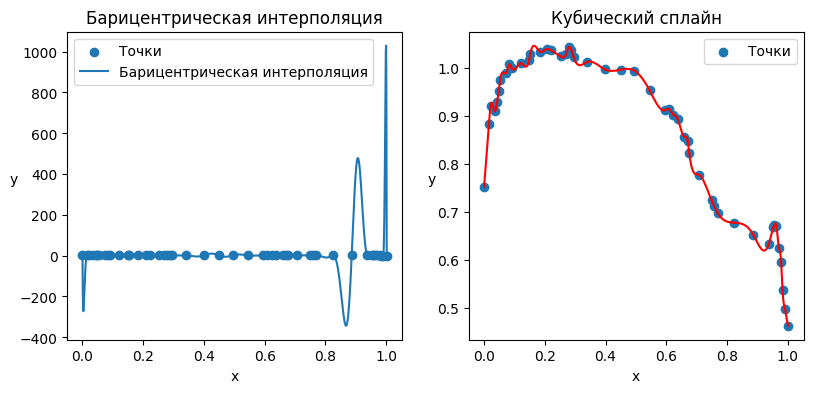

In [226]:
bins = np.linspace(x[0], x[-1], 1000)
y_interp = barycentric_interpolate(x, y, bins)


s0, s1, s2, s3 = cubic_spline(x, y, -1)


fig, ax = plt.subplots(ncols=2, figsize=(9.5, 4))

ax[0].scatter(x, y, label='Точки')
ax[0].plot(bins, y_interp, label='Барицентрическая интерполяция')
ax[0].legend()
ax[0].set_xlabel('x')
ax[0].set_ylabel('y', rotation=0)
ax[0].set_title('Барицентрическая интерполяция')

ax[1].scatter(x, y, label='Точки')
plot_cubic_spline(x, s0, s1, s2, s3)
ax[1].legend()
ax[1].set_xlabel('x')
ax[1].set_ylabel('y', rotation=0)
ax[1].set_title('Кубический сплайн')

plt.savefig('figure1.png', dpi=300)
plt.legend()


In [ ]:
def cubic_spline_parametrix(x, y, der_b):
    t = np.zeros_like(x, dtype=np.float32)
    t[1:] = np.cumsum(np.sqrt((x[1:] - x[:-1]) ** 2 + (y[1:] - y[:-1]) ** 2))
    h = x[1:] - x[:-1]
    d = (y[1:] - y[:-1]) / h
    b = 6 * (d[1:] - d[:-1])

    A_up = np.diag(h[1:-1], k=1)
    A_middle = np.diag(2 * (h[1:] + h[:-1]), k=0)
    A_down = np.diag(h[1:-1], k=-1)

    A = A_up + A_middle + A_down

    A[-1][-1] -= 0.5 * h[-1]
    b[-1] -= 3 * (der_b - d[-1])

    m = np.linalg.solve(A, b)

    m_0 = 0
    m_N = 3 / h[-1] * (der_b - d[-1]) - m[-1] / 2

    m = np.hstack([m_0, m, m_N])

    s0 = y[:-1]
    s1 = d - h / 6 * (2 * m[:-1] + m[1:])
    s2 = m[:-1] / 2
    s3 = (m[1:] - m[:-1]) / (6 * h)
    return s0, s1, s2, s3